# Using Shap for explinability


## Set up the environment
* Load libraries

In [14]:
import pickle
import shap
import pandas as pd
import numpy as np

# Load Data

In [31]:
lgbm_model = pickle.load(open('../../models/optuna_model.pkl', 'rb'))
oot = pd.read_parquet('../../data/oot_data.parquet')
oot_y = oot['is_fraud']
oot_X = oot.drop(columns=['is_fraud'] ) #+ metadata_columns)

train = pd.read_parquet('../../data/train_data.parquet')
train_y = train['is_fraud']
train_X = train.drop(columns=['is_fraud'])
train_X = train_X[lgbm_model.feature_name_]

* Evaluate Shap

In [38]:
# print the JS visualization code to the notebook
shap.initjs()
explainer = shap.TreeExplainer(lgbm_model,feature_perturbation="tree_path_dependent")

## UNDERSTAND THE MODEL
*use shap on entire model to explain importance on training*

In [33]:
shap_values_train = explainer(train_X)

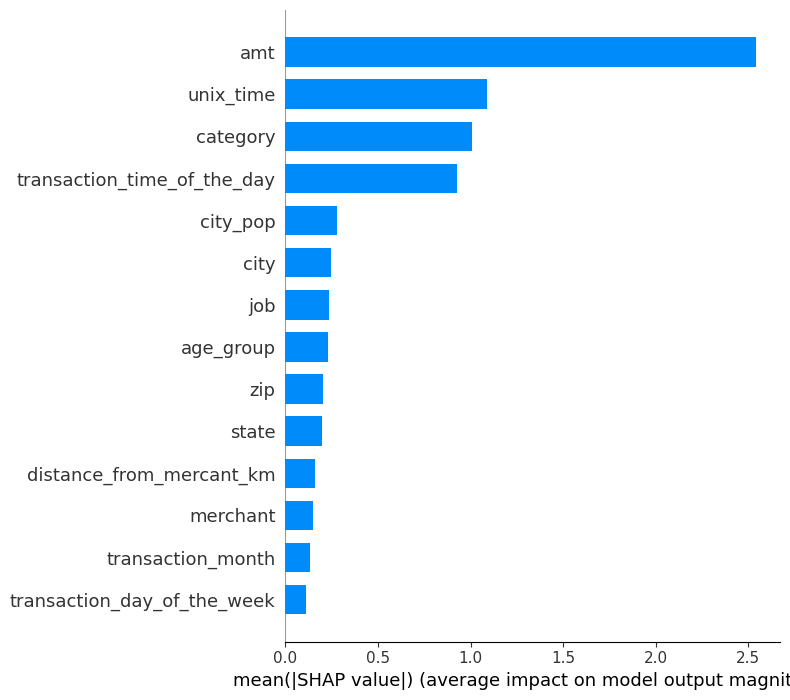

In [35]:
shap.summary_plot(shap_values, train_X, plot_type="bar")

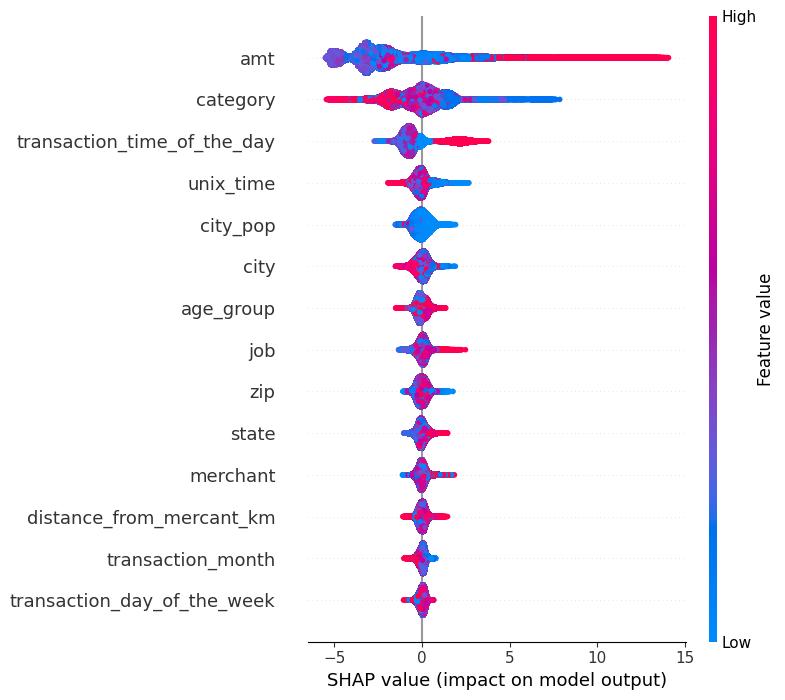

In [ ]:
#use a density scatter plot of SHAP values for each feature to identify how much impact each feature has on the model output for individuals in the validation dataset.
shap.summary_plot(shap_values_train, train_X)

In [37]:
# dependence plot
for name in lgbm_model.feature_name_:
    shap.dependence_plot(name, shap_values_train, train_X)#, display_features=train_X)

TypeError: loop of ufunc does not support argument 0 of type Explanation which has no callable conjugate method

name

## INVESTIGATE PREDICTIONS
**Return info on a single decision**

### support function

In [49]:
transaction_index = np.random.randint(0, len(oot_X))
transaction_id = oot_X.index[transaction_index]
shap_values = explainer(oot_X[lgbm_model.feature_name_])

In [50]:
shap.force_plot(explainer.expected_value, shap_values.values[transaction_index, :], oot_X.iloc[transaction_index][lgbm_model.feature_name_])

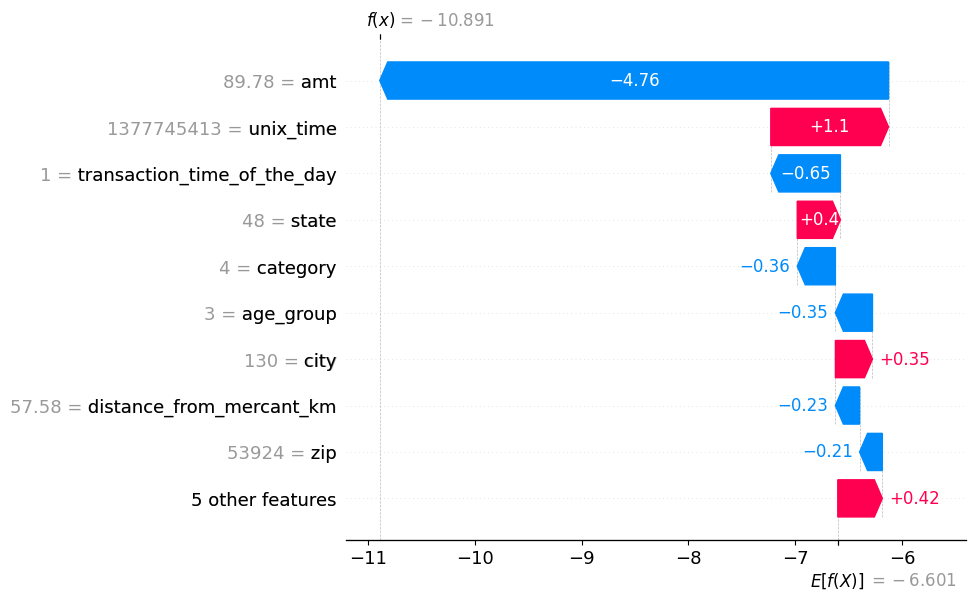

In [51]:
plot =  shap.plots.waterfall(shap_values[transaction_index,:])

---